#  Linear Regression on Advertising Dataset

##  Objective
To predict sales based on advertising spend (TV, Radio, Newspaper)

##  Steps
- Data Loading
- EDA (Visualization)
- Feature Selection
- Model Training
- Evaluation

## To predict total sales by using features like money spent on marketing on indivdual items.

## Domain Analysis

In [3]:
#importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
#Loading the data
data=pd.read_csv(r"C:\Users\admin\Downloads\Advertising.csv")

In [12]:
## Call the dataframe and do basic checks
data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [13]:
data.tail()

,Unnamed: 0,TV,Radio,Newspaper,Sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [14]:
data.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [15]:
data.info()
# No missing values in the data.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


## Exploratory Data Analysis

In [16]:
data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


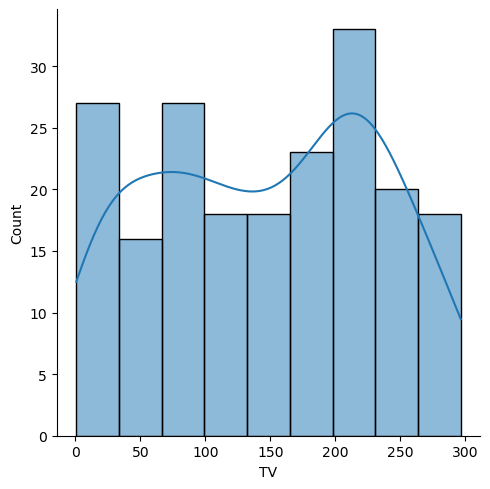

In [17]:
#Step 1 Univariate Analysis

#Analyzing TV
sns.displot(x=data.TV,kde=True)

<Axes: xlabel='Radio', ylabel='Count'>

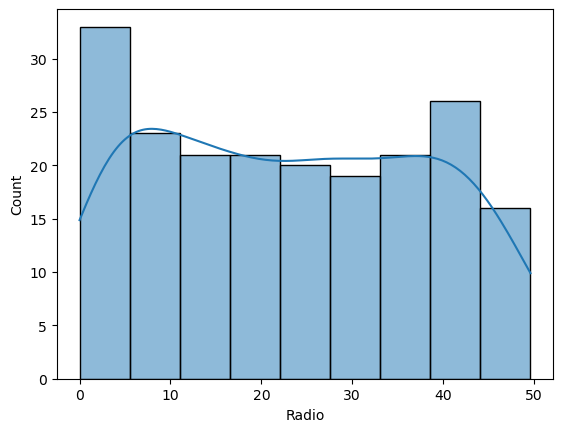

In [18]:
# Analyszing Radio
sns.histplot(x=data.Radio,kde=True)

<Axes: xlabel='Newspaper', ylabel='Count'>

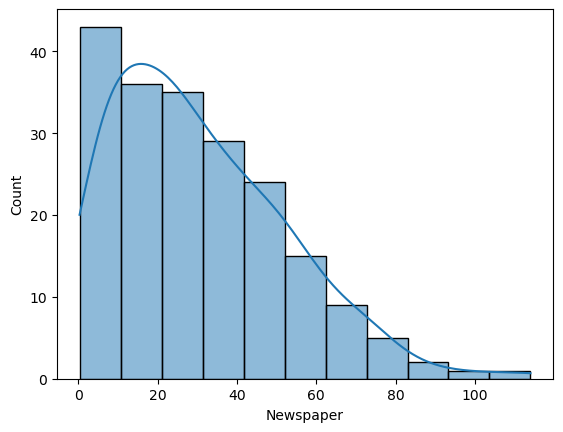

In [19]:
# Aanalyzing Newspaper
sns.histplot(x=data.Newspaper,kde=True)
# By looking at below plot we can say that there are less than 10 months when the marketing cost was high 

In [20]:
# Step 2 Bivariate Analysis
# This step is performed when inputs and output are known.
# 1st variable will be Inputs
# 2nd variable will be output/target variable.

In [21]:
data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


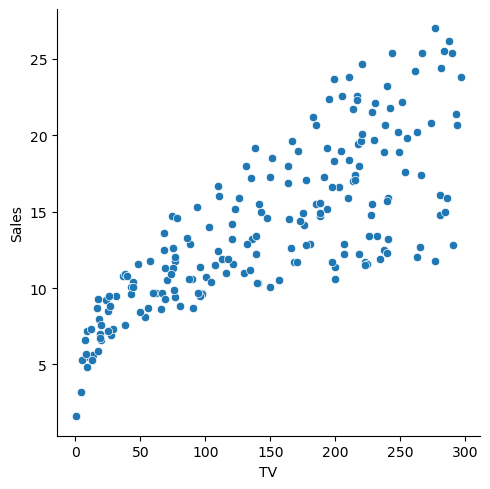

In [22]:
# Analyzing TV and Sales
sns.relplot(x='TV',y='Sales',data=data)
# The more marketing on TV is leading to more sales in the product.

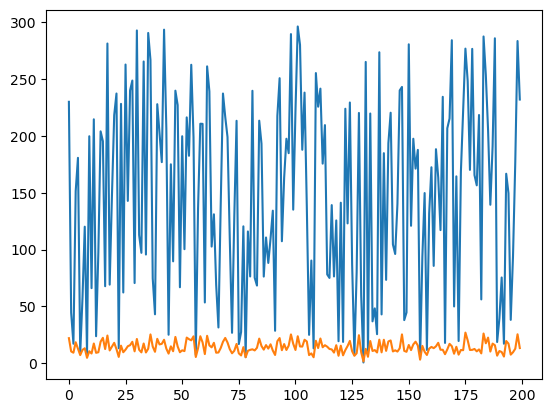

In [23]:
plt.plot(data.TV)
plt.plot(data.Sales)

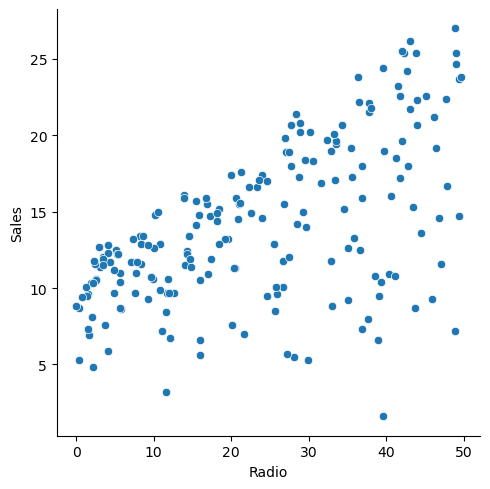

In [24]:
# Analyzing Radio and Sales
sns.relplot(x='Radio',y='Sales',data=data)
# Radio advertisments are not showing much trend for the sales of product.

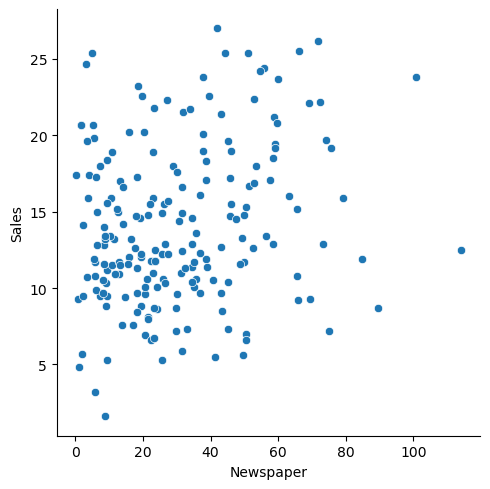

In [25]:
# Analyzing Newsapaper and Sales
sns.relplot(x='Newspaper',y='Sales',data=data)
# Newspaper advertisments are not showing much trend for the sales of product.

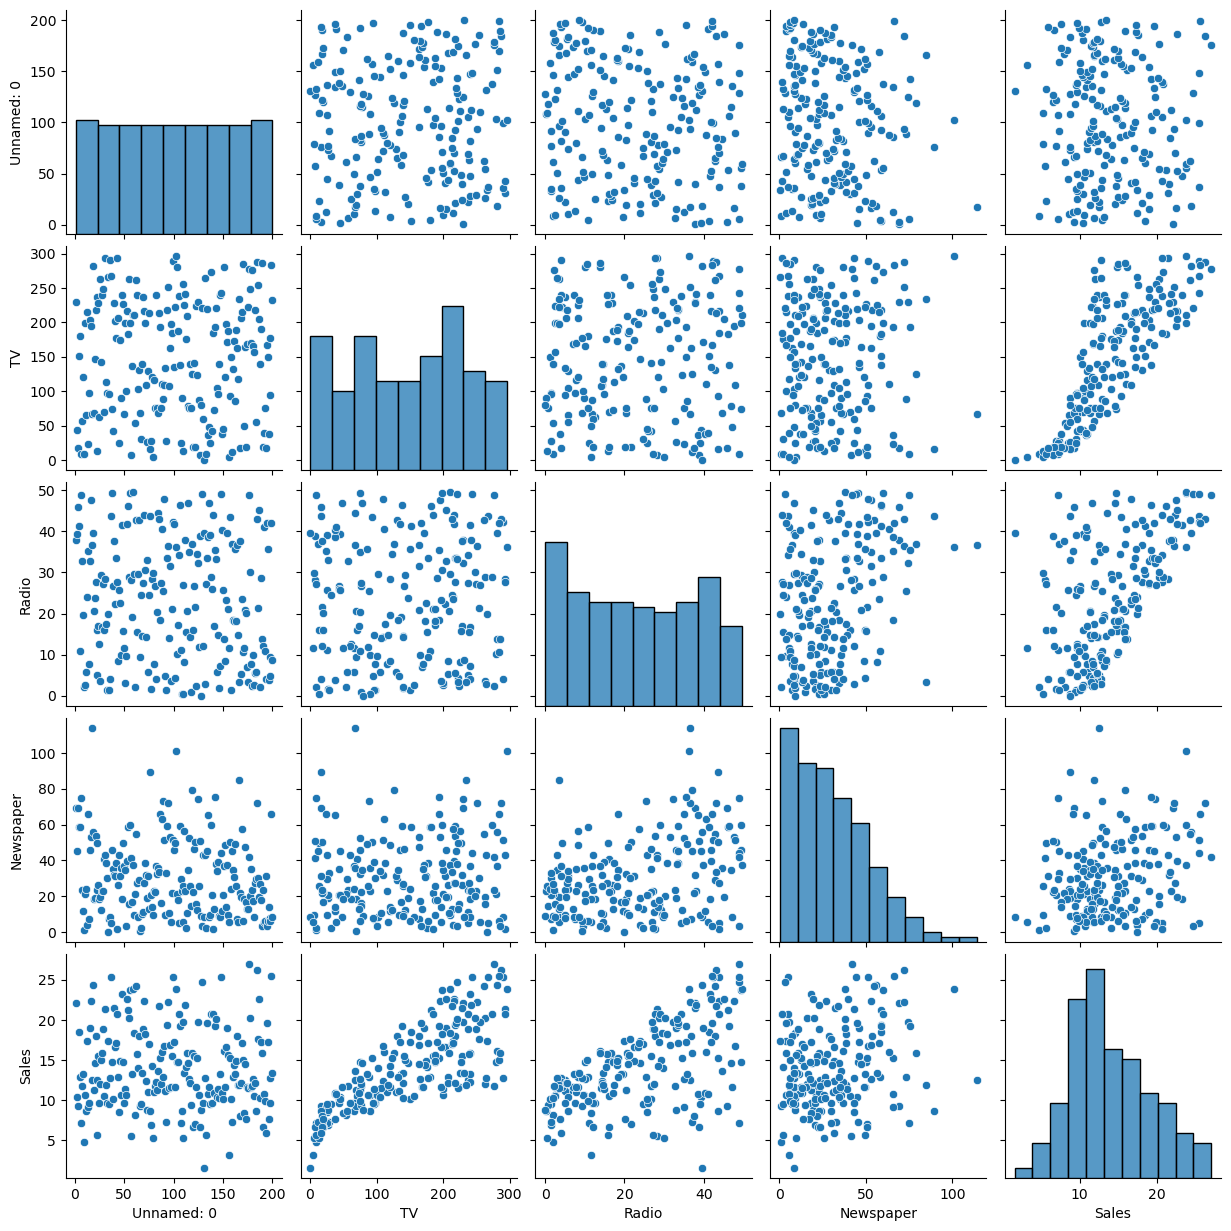

In [26]:
## Step 3 Multivariate Analysizing
sns.pairplot(data)

## Data Preprocessing and Feature Engineering

In [27]:
# Step 1-Finding missing values
data.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [28]:
#Step 2- Converting categorical data to numerical

<Axes: xlabel='TV'>

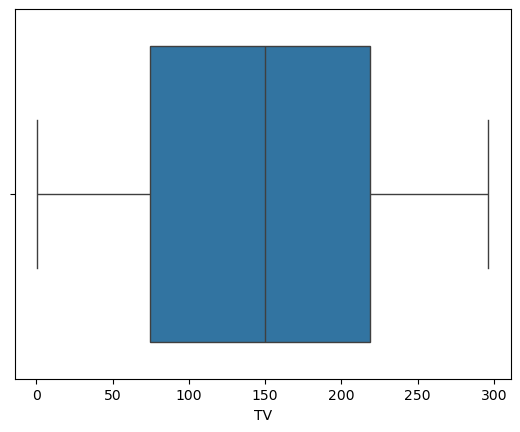

In [29]:
# Step 3 Checking the outlier
sns.boxplot(x='TV',data=data)

<Axes: xlabel='Radio'>

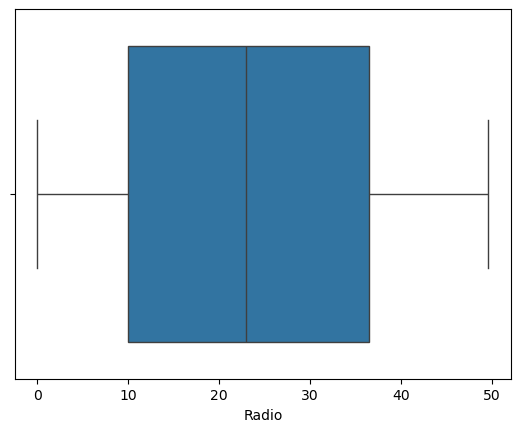

In [30]:
sns.boxplot(x='Radio',data=data)

<Axes: xlabel='Newspaper'>

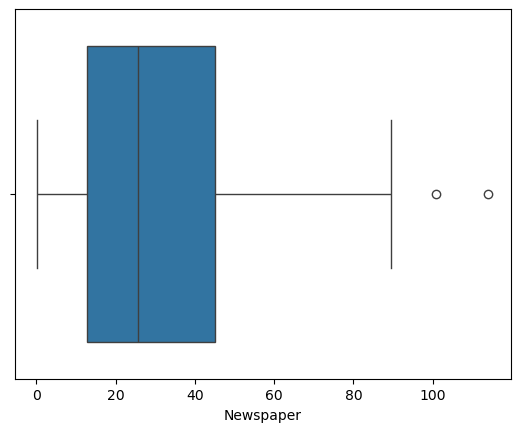

In [31]:
sns.boxplot(x='Newspaper',data=data)

In [ ]:
### Step 4 Scaling the continous variable
#Intentionally skipping this step.

In [50]:
# Step 5 Transformation
#Intentionally skipping this step

In [51]:
# Step 6 Balacing the data
#THis step is performed specially for classification

### Feature Selection

In [52]:
#Step 1 Dropping the unwanted variables
l1=['Unnamed: 0']
data.drop(l1,axis=1,inplace=True)

In [53]:
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


<Axes: >

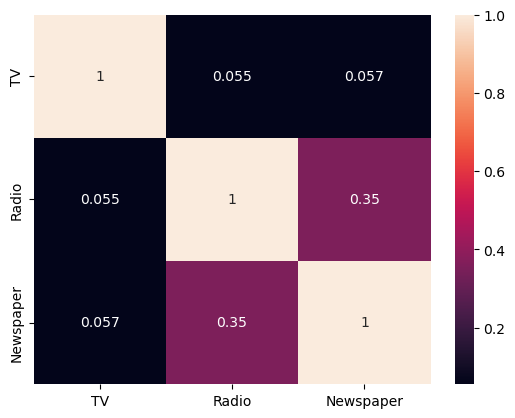

In [54]:
## Step 2 Checking the correlation
sns.heatmap(data.drop('Sales',axis=1).corr(),annot=True)

In [55]:
data.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


## Model Creation

In [56]:
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [57]:
#Step 1 Independent and dependent variable creation
X=data[['TV','Radio','Newspaper']] ## X variable contains all inputs
y=data.Sales ## y is output

In [58]:
y

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: Sales, Length: 200, dtype: float64

In [59]:
# Step 2 Traning and testing data creation
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=4)

In [36]:
y_train

26     15.0
134    10.8
180    10.5
158     7.3
189     6.7
       ... 
104    20.7
129     9.7
183    26.2
174    11.5
122    11.6
Name: Sales, Length: 160, dtype: float64

In [37]:
# Step 3 Creating model
from sklearn.linear_model import LinearRegression
LR=LinearRegression() # object creation
LR.fit(X_train,y_train) # training of linear regression
y_predict=LR.predict(X_test)

In [38]:
y_test # Actual values

11     17.4
99     17.2
128    24.7
175    27.0
1      10.4
111    21.8
90     11.2
177    11.7
88     12.9
187    17.3
61     24.2
199    13.4
191     9.9
123    15.2
184    17.6
188    15.9
33     17.4
171    14.5
138     9.6
84     21.7
81     12.3
102    14.8
147    25.4
34      9.5
47     23.2
124    19.7
112    14.1
6      11.8
14     19.0
190    10.8
80     11.8
18     11.3
167    12.2
45     14.9
153    19.0
119     6.6
100    11.7
83     13.6
181    12.2
71     12.4
Name: Sales, dtype: float64

In [39]:
y_predict # Values predicted by model

array([17.2752476 , 16.74844593, 21.97674588, 24.59448907, 12.11768831,
       21.02033688, 10.15643252, 12.34380805, 11.70461016, 17.02091374,
       22.77376935, 15.3468411 ,  8.47830473, 14.9155752 , 18.61592987,
       18.78535771, 18.92262443, 14.411111  ,  9.65948532, 20.60497137,
       14.91294261, 17.84682569, 23.05099966,  7.74477655, 21.55734502,
       19.45793001, 13.93893979, 11.55855542, 18.37843109, 12.19352005,
       11.35032808,  9.91369153, 13.57335272, 15.18177818, 18.06379607,
        6.80705318, 14.14598886, 14.14649594, 14.1536933 , 10.69806825])

In [40]:
# Step 4 Model Evalution

from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
r2score=r2_score(y_test,y_predict)

In [41]:
r2score

0.9085774752313167

In [42]:
X_test.shape

(40, 3)

In [43]:
## calculation of adjusted r2 score
adjusted_r2 = 1-(1-0.90)*(40-3)/(40-3-1)
adjusted_r2

0.8972222222222223

In [44]:
import math
print(mean_squared_error(y_test,y_predict))
print(math.sqrt(mean_squared_error(y_test,y_predict))) # root mean squared error

2.217151072541898
1.4890100982001089


In [45]:
print(mean_absolute_error(y_test,y_predict))

1.2114892606469108
